# 1. Importación de librerías

In [1]:
import re
import linecache
import matplotlib.pyplot as plt
import numpy as np

from smart_open import open
import nltk

nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

# 2. Procesamiento del corpus

En esta sección nos familiazaremos con el corpus que vamos a usar para entrenar nuestro modelo de lenguaje de n-gramas. Adicionalmente, se aplican algunas técnicas de procesamiento de texto para mejorar el desempeño de nuestros modelos.

En este tutorial usaremos el libro "English Fairy Tales" de Flora Annie Webster Steel como corpus. Este libro consiste en una serie de cuentos infantiles. El libro se puede encontar en Proyecto Gutenberg y puede ser visualizado o descargado directamente [aquí](https://www.gutenberg.org/ebooks/17034).

In [2]:
BOOK_PATH = 'english_fairy_tales.txt'

Como primer paso definimos el objetivo de nuestro modelo de lenguaje. En este caso vamos a crear un modelo de lenguaje capaz de generar oraciones de texto relacionadas a cuentos infantiles.

Por lo tanto, en primera instancia vamos a crear secuencias de texto a partir del corpus extrayendo las oraciones presentes en en corpus, y guardandolas en otro archivo de texto bajo el nombre de `corpus.txt`.

In [3]:
CORPUS_PATH = 'corpus.txt'

with open(BOOK_PATH, 'r') as f:
    book = f.readlines()

# Solo se toman en cuenta las líneas que contienen el texto del libro
book = ''.join(book[299:9547])

# Se eliminan multiples espacios en blanco
book = re.sub(r'\s+', ' ', book)

# Se extraen las oraciones del libro
sentences = nltk.sent_tokenize(book)

# Se elimina el archivo corpus.txt si ya existe
import os
if os.path.exists(CORPUS_PATH):
    os.remove(CORPUS_PATH)

# Se escribe cada oración en el archivo corpus.txt para facilitar su posterior procesamiento
for sentence in sentences:
    with open(CORPUS_PATH, 'a') as f:
        f.write(sentence + '\n')
        
print(f"El libro tiene un total de {len(sentences):,} oraciones.")

El libro tiene un total de 3,899 oraciones.


Creamos una clase para cargar el corpus que sea capaz de procesar el texto y entregarnos una a una las secuencias de texto procesadas.

Para realizar el procesamiento de texto usaremos `nltk.word_tokenize` para tokenizar las oraciones en palabras, y trataremos los caracteres de puntuación como una palabra aparte.

In [5]:
class Corpus:
    """Clase que permite leer un archivo de texto línea por línea y procesarla recibiendo como entrada la ruta del archivo."""
    def __init__(self, path: str):
        """
        La clase se inicializa con la ruta del archivo de texto que se desea utilizar como corpus. Cada línea del archivo
        debe contener una oración.

        Args:
            path (str): Ruta del archivo de texto que se desea utilizar como corpus.
        """
        self.path = path

    def _preprocess(self, line):
        """
        Método que recibe una línea de texto y la preprocesa para tokenizarla y agregar los tokens de inicio y fin de la secuencia.

        Args:
            line (str): Línea de texto que se desea preprocesar.
        """
        return ['<START>'] + nltk.word_tokenize(line) + ['<END>']

    def __iter__(self) -> "iter[list[str]]":
        """
        Método que permite iterar sobre el corpus línea por línea.

        Returns:
            Un objeto iterable con la lista de tokens por oración del corpus.
        """
        with open(self.path) as f:
            for line in f:
                # Se preprocesa la línea al momento de leerla
                yield self._preprocess(line)

    def __len__(self) -> int:
        """
        Método que permite obtener la cantidad de líneas que contiene el corpus.
        """
        with open(self.path) as f:
            return sum(1 for _ in f)
        
    def __getitem__(self, index: int) -> "list[str]":
        """
        Método que permite obtener una línea específica del corpus.

        Args:
            index (int): Índice de la línea que se desea obtener.

        Returns:
            list: Lista de tokens que representan una oración del corpus.
        """
        return self._preprocess(linecache.getline(self.path, index + 1))

# Se crea una instancia de la clase Corpus
corpus = Corpus(CORPUS_PATH)
print(f'El corpus contiene {len(corpus):,} oraciones.')

El corpus contiene 3,899 oraciones.


Ejemplo de las primeras 6 oraciones del corpus:

In [6]:
for i, sentence in enumerate(corpus):
    if i > 5:
        break
    print(sentence)

['<START>', 'ST.', 'GEORGE', 'OF', 'MERRIE', 'ENGLAND', 'In', 'the', 'darksome', 'depths', 'of', 'a', 'thick', 'forest', 'lived', 'Kalyb', 'the', 'fell', 'enchantress', '.', '<END>']
['<START>', 'Terrible', 'were', 'her', 'deeds', ',', 'and', 'few', 'there', 'were', 'who', 'had', 'the', 'hardihood', 'to', 'sound', 'the', 'brazen', 'trumpet', 'which', 'hung', 'over', 'the', 'iron', 'gate', 'that', 'barred', 'the', 'way', 'to', 'the', 'Abode', 'of', 'Witchcraft', '.', '<END>']
['<START>', 'Terrible', 'were', 'the', 'deeds', 'of', 'Kalyb', ';', 'but', 'above', 'all', 'things', 'she', 'delighted', 'in', 'carrying', 'off', 'innocent', 'new-born', 'babes', ',', 'and', 'putting', 'them', 'to', 'death', '.', '<END>']
['<START>', 'And', 'this', ',', 'doubtless', ',', 'she', 'meant', 'to', 'be', 'the', 'fate', 'of', 'the', 'infant', 'son', 'of', 'the', 'Earl', 'of', 'Coventry', ',', 'who', 'long', 'long', 'years', 'ago', 'was', 'Lord', 'High', 'Steward', 'of', 'England', '.', '<END>']
['<START>'

# 3. Constuir el vocabulario del corpus

Construimos el vocabulario del corpus para tener una idea de como quedaron conformados los tokens, saber el tamaño del vocabulario, y tener la frecuencia de cada token.

In [7]:
vocabulary = {}
# Iterar por cada oración en el corpus
for sentence in corpus:
    # Iterar por cada token en la oración
    for token in sentence:
        # Agregar el token al vocabulario y aumentar su frecuencia
        vocabulary[token] = vocabulary.get(token, 0) + 1

print(f'El corpus tiene un vocabulario de {len(vocabulary):,} tokens.')

El corpus tiene un vocabulario de 6,033 tokens.


In [8]:
sorted_vocabulary = sorted(vocabulary.items(), key=lambda x: x[1], reverse=True)

print(f'Los 10 tokens más frecuentes son: {sorted_vocabulary[:10]}')
print(f'Los 10 tokens menos frecuentes son: {sorted_vocabulary[-10:]}')

Los 10 tokens más frecuentes son: [(',', 6385), ('the', 4888), ('<START>', 3899), ('<END>', 3899), ('and', 3486), ('.', 2872), ('to', 2045), ('a', 1668), ('he', 1541), ('of', 1385)]
Los 10 tokens menos frecuentes son: [('perching', 1), ('Dead', 1), ('hurriedly', 1), ('Hark', 1), ('Perhaps', 1), ('rose-coloured', 1), ('blossomed', 1), ('edged', 1), ('blossom', 1), ('tuft', 1)]


Como se observa dentro de los tokens más frecuentes se tienen los tokens de inicio y final de la secuencia, junto con caracteres de puntuación, artículos y pronombres del lenguaje.

Por otro lado, los tokens menos frecuentes son palabras que en este caso tienen una única frecuencia en el corpus. Para nuestra sorpresa, se encuentran palabras relativamente comunes como "Dead" y "Perhaps". Esto es un indicativo del pequeño tamaño del corpus y también se debe tener en cuenta, que para este caso no se realizó transformación a minúsculas ni normalización de palabras que podrían ser técnicas útiles de procesamiento en este escenario.

Veamos la distribución de las frecuencias de nuesto vocabulario:

Text(0, 0.5, 'Number of words')

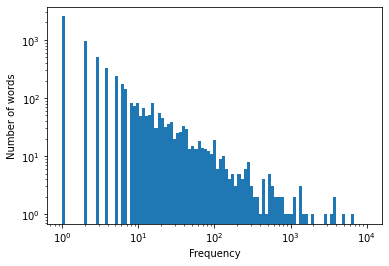

In [9]:
frequencies = list(vocabulary.values())
plt.hist(frequencies, bins=np.logspace(0, 4, 100))
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.xlabel('Frequency')
plt.ylabel('Number of words')

En esta gráfica podemos ver como la distribución de las frecuencias de las palabras no es densa. Es decir, que tenemos varias frecuencias para las cuales no hay palabras en el vocabulario, lo que sería otro indicativo del pequeño tamaño del corpus. Además, el número de palabras con una frecuencia menor a 10 palabras es alta, por lo que no podríamos realizar estimaciones de probabilidad precisas para estas palabras. En el caso de n-gramas este problema cobraría mayor relevancia al tener conteos muy bajos para las combinaciones posibles de las palabras de nuestro vocabulario.

# 4. Entrenando modelos de lenguaje de n-gramas.

En esta sección vamos a entrenar modelos de lenguaje con n-gramas. Inicialmente se introducirá la construcción de este tipo de modelos usando bigramas.

El objetivo principal de los modelos de lenguaje que vamos a construir es poder calcular la probabilidad de ocurrencia de una palabra con $n-1$ palabras de contexto. Más específicamente, para un modelo de bigramas queremos calcular:

$P(w_i|w_{i-1}) = \frac{\text{count}(w_{i-1}, w_i)}{\text{count}(w_{i-1})}$

Es decir, que para el caso de bigramas podemos aproximar la probabilidad de una palabra dada la palabra anterior simplemente contando cuantas veces vemos las dos palabras juntas, sobre el número de veces que la palabra anterior está presente en el corpus.

Para el caso de n-gramas tenemos que:

$P(w_i|w_{i-n}...w_{i-1}) = \frac{\text{count}(w_{i-n}, ..., w_i)}{\text{count}(w_{i-n}, w_{i-1})}$

Por lo tanto, para constuir un modelo de n-gramas capaz de calcular la probabilidad de la palabra i con un contexto de palabras anteriores ($n-1$) solo necesitamos calcular dos frecuencias. La frecuencia con que se presenta la palabra i seguida del contexto en el corpus, y la frecuencia de las palabras de contexto en el corpus.

## 4.1 Ejemplo de modelos de bigramas

Para construir un modelo de bigramas que genere lenguaje debemos ser capaces de calcular la probabilidad de cualquier bigrama. Que como lo vimos arriba esto se traduce en contar el número de bigramas vistos en el corpus, y contar el número de unigramas.

El objetivo será utilizar la estimación de la probabilidad de los bigramas para generar una secuencia de texto.

Antes de calcular las frecuencias de los bigramas debemos ser capaces de identificar todos los bigramas que observamos en cada secuencia del corpus:

In [10]:
sample_seq = corpus[0]
print("Ejemplo de una secuencia de tokens del corpus:")
print(sample_seq)

# Debemos identificar todos los bigramas observados
n = 2
print(f"Bigramas observados en la secuencia de ejemplo:")
for i in range(len(sample_seq) - n + 1):
    print(sample_seq[i:i+n])

Ejemplo de una secuencia de tokens del corpus:
['<START>', 'ST.', 'GEORGE', 'OF', 'MERRIE', 'ENGLAND', 'In', 'the', 'darksome', 'depths', 'of', 'a', 'thick', 'forest', 'lived', 'Kalyb', 'the', 'fell', 'enchantress', '.', '<END>']
Bigramas observados en la secuencia de ejemplo:
['<START>', 'ST.']
['ST.', 'GEORGE']
['GEORGE', 'OF']
['OF', 'MERRIE']
['MERRIE', 'ENGLAND']
['ENGLAND', 'In']
['In', 'the']
['the', 'darksome']
['darksome', 'depths']
['depths', 'of']
['of', 'a']
['a', 'thick']
['thick', 'forest']
['forest', 'lived']
['lived', 'Kalyb']
['Kalyb', 'the']
['the', 'fell']
['fell', 'enchantress']
['enchantress', '.']
['.', '<END>']


Para que el entrenamiento del modelo sea eficiente debemos encontrar una forma de contar los n-gramas (n palabras seguidas) y el contexto ($n-1$ palabras seguidas) con una sola iteración por todo el corpus.

In [11]:
sample_seq = ['hola', ',', 'como', 'estas', '?', 'hola', ',', 'que', 'tal', '?', 'hola']
print(sample_seq)

# Vamos a crear dos diccionarios para guardar los bigramas y los contextos observados junto con su frecuencia
bigrams = {}
context = {}

n = 2
for i in range(len(sample_seq)):
    observed_context = sample_seq[i]
    observed_bigram = tuple(sample_seq[i:i+n]) # Convertimos el bigrama a una tupla para poder usarlo como llave del diccionario.

    # Se aumentan los conteos para los bigramas y para el contexto (unigrama)
    context[observed_context] = context.get(observed_context, 0) + 1
    # Si el tamaño del bigrama no es igual n es porque ya estamos en el final de la secuencia y no hay suficientes tokens para formar un bigrama
    if len(observed_bigram) == n:
        bigrams[observed_bigram] = bigrams.get(observed_bigram, 0) + 1

print(context)
print(bigrams)

['hola', ',', 'como', 'estas', '?', 'hola', ',', 'que', 'tal', '?', 'hola']
{'hola': 3, ',': 2, 'como': 1, 'estas': 1, '?': 2, 'que': 1, 'tal': 1}
{('hola', ','): 2, (',', 'como'): 1, ('como', 'estas'): 1, ('estas', '?'): 1, ('?', 'hola'): 2, (',', 'que'): 1, ('que', 'tal'): 1, ('tal', '?'): 1}


Generalizamos el conteo de frecuencias para n-gramas

In [12]:
def n_grams_freq(n_grams_dict: dict, context_dict: dict, n: int, corpus: iter):
    """
    Función para calcular la frecuencia de n-gramas y del contexto en el corpus.

    Args:
        n_grams_dict (dict): Diccionario para almacenar las frecuencias de los n-gramas.
        context_dict (dict): Diccionario para almacenar las frecuencias del contexto.
        n (int): Número de n-gramas a usar.
        corpus (iter): Iterable con una lista de tokens por secuencia de texto en el corpus.path

    """
    context_length = n - 1
    for sentence in corpus:
        for i in range(len(sentence) - context_length + 1): # Nos interesa contar sequencias de mínimo el contexto de largo
            observed_context = tuple(sentence[i:i+context_length])
            observed_n_gram = tuple(sentence[i:i+n])
            context_dict[observed_context] = context_dict.get(observed_context, 0) + 1
            if len(observed_n_gram) == n:
                n_grams_dict[observed_n_gram] = n_grams_dict.get(observed_n_gram, 0) + 1

trigrams = {}
bigrams = {}
sample_seq = ['hola', ',', 'como', 'estas', '?', 'hola', ',', 'que', 'tal', '?', 'hola' , ',', 'como', 'te', 'va', '?']
n_grams_freq(trigrams, bigrams, 3, [sample_seq])
print(bigrams)
print(trigrams)

{('hola', ','): 3, (',', 'como'): 2, ('como', 'estas'): 1, ('estas', '?'): 1, ('?', 'hola'): 2, (',', 'que'): 1, ('que', 'tal'): 1, ('tal', '?'): 1, ('como', 'te'): 1, ('te', 'va'): 1, ('va', '?'): 1}
{('hola', ',', 'como'): 2, (',', 'como', 'estas'): 1, ('como', 'estas', '?'): 1, ('estas', '?', 'hola'): 1, ('?', 'hola', ','): 2, ('hola', ',', 'que'): 1, (',', 'que', 'tal'): 1, ('que', 'tal', '?'): 1, ('tal', '?', 'hola'): 1, (',', 'como', 'te'): 1, ('como', 'te', 'va'): 1, ('te', 'va', '?'): 1}


Ahora encontremos las frecuencias de los bigramas y los unigramas para todo el corpus

In [13]:
unigrams = {}
bigrams = {}
n_grams_freq(bigrams, unigrams, 2, corpus)

In [14]:
len(bigrams), len(unigrams)

(35783, 6033)

Note como las combinaciones de bigramas crecieron significativamente frente al número de unigramas del corpus.

# 4.2 Entrenando otros modelos de n-gramas

Ahora hagamos una comparativa encontrando los 4-gramas y trigramas del corpus

In [15]:
four_grams = {}
trigrams = {}
n_grams_freq(four_grams, trigrams, 4, corpus)

In [16]:
len(four_grams), len(trigrams)

(77545, 65718)

Las combinaciones siguen creciendo a medida que aumentamos los n-gramas. Sin embargo, debido al tamaño del corpus y a la estructura del lenguaje natural es normal que la tasa de crecimiento de las combinaciones observadas decrezca. A continuación veamos la distribución de la frecuencia de las combinaciones para los distintos modelos de n-gramas:

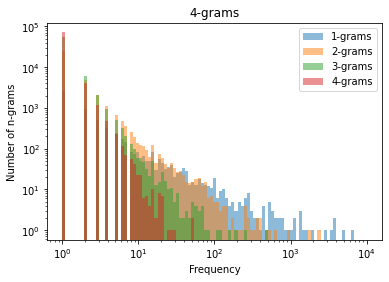

In [17]:
to_plot = {1: unigrams, 2: bigrams, 3: trigrams, 4: four_grams}

for n, n_grams in to_plot.items():
    frequencies = list(n_grams.values())
    plt.hist(frequencies, bins=np.logspace(0, 4, 100), label=f'{n}-grams', alpha=0.5)

plt.legend()
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.xlabel('Frequency')
plt.ylabel('Number of n-grams')
plt.title(f'{n}-grams')
plt.show()

Como observamos anteriormente, a medida que incrementamos el valor de n-gramas se tienen cada vez más combinaciones. Pero las combinaciones tienen cada vez menos frecuencias, lo que causa que las estimaciones de probabilidad sean menos precisas a medida que aumentamos n. En especial se evidencia como para el caso de 4-gramas parece que ninguna combinación tiene un conteo superior a 100, y la gran mayoría de combinaciones tienen conteos menores a 10.

# 5. Estimación de probabilidad de una secuencia de texto

Con las frecuencias de n-gramas que encontramos es posible encontrar la probabilidad de una secuencia de texto. En este caso vamos a calcular la probabilidad que asignan nuestros modelos de n-gramas a una secuencia que se encuentra en el corpus de entrenamiento.

Recordemos que para calcular la probabilidad de una secuencia de texto, vamos a realizar estimaciones según la cantidad de n-gramas de los que disponemos. Por ejemplo para calcular la probabilidad de "hola, que tal?", tenemos que:

Modelo de unigramas:
$P(\text{"hola"},\text{","},\text{"que"},\text{"tal"},\text{"?"}) = P(\text{"hola"})P(\text{","})P(\text{"que"})P(\text{"tal"})P(\text{"?"})$

Modelo de bigramas:
$P(\text{"hola"},\text{","},\text{"que"},\text{"tal"},\text{"?"}) = P(\text{","}|\text{"hola"})P(\text{"que"}|\text{","})P(\text{"tal"}|\text{"que"})P(\text{"?"}|\text{"tal"})$

Modelo de trigramas:
$P(\text{"hola"},\text{","},\text{"que"},\text{"tal"},\text{"?"}) = P(\text{"que"}|\text{"hola"},\text{","})P(\text{"tal"}|\text{","},\text{"que"})P(\text{"?"}|\text{"que"},\text{"tal"})$

Modelo de 4-gramas:
$P(\text{"hola"},\text{","},\text{"que"},\text{"tal"},\text{"?"}) = P(\text{"tal"}|\text{"hola"},\text{","},\text{"que"})P(\text{"?"}|\text{","},\text{"que"},\text{"tal"})$

In [18]:
sample_seq = corpus[2]
print(' '.join(sample_seq))

p_1_gram = 0
p_2_gram = 0
p_3_gram = 0
p_4_gram = 0

for token in sample_seq:
    p_1_gram += np.log(unigrams[(token,)] / len(unigrams))

for i in range(len(sample_seq) - 1):
    p_2_gram += np.log(bigrams[(sample_seq[i], sample_seq[i+1])] / unigrams[(sample_seq[i],)])

for i in range(len(sample_seq) - 2):
    p_3_gram += np.log(trigrams[(sample_seq[i], sample_seq[i+1], sample_seq[i+2])] / bigrams[(sample_seq[i], sample_seq[i+1])])

for i in range(len(sample_seq) - 3):
    p_4_gram += np.log(four_grams[(sample_seq[i], sample_seq[i+1], sample_seq[i+2], sample_seq[i+3])] / trigrams[(sample_seq[i], sample_seq[i+1], sample_seq[i+2])])

print(np.exp(p_1_gram))
print(np.exp(p_2_gram))
print(np.exp(p_3_gram))
print(np.exp(p_4_gram))

<START> Terrible were the deeds of Kalyb ; but above all things she delighted in carrying off innocent new-born babes , and putting them to death . <END>
2.1834528333809388e-47
2.3992809514220413e-40
3.572811606801559e-11
0.12500000000000003


Observe como el modelo de 4-gramas es el modelo que asigna mayor probabilidad a la secuencia, y por lo tanto, sería el mejor. Sin embargo se debe tener en cuenta que la evaluación debe hacerse en el set dispuesto con el propósito de evaluar el modelo.

Adicionalmente, note que los valores de probabilidad son muy pequeños. Tradicionalmente para evaluar los modelos de lenguaje se usa la métrica de perplejidad, que corresponde al valor inverso de la probabilidad de la secuencia pero normalizado por el número n-gramas de la secuencia.

In [19]:
print((np.exp(p_1_gram))**(-1/len(sample_seq)))
print((np.exp(p_2_gram))**(-1/(len(sample_seq) - 1)))
print((np.exp(p_3_gram))**(-1/(len(sample_seq) - 2)))
print((np.exp(p_4_gram))**(-1/(len(sample_seq) - 3)))

46.393714915814314
29.336236862111164
2.5223613505031692
1.086734862526058


# 6. Palabras fuera del vocabulario y suavizado de Laplace

¿Qué pasa con secuencias de texto que no fueron observadas en el corpus?

In [20]:
sample_seq = ["it", "was", "very", "sad"]
print(' '.join(sample_seq))

p_1_gram = 0
p_2_gram = 0
p_3_gram = 0
p_4_gram = 0

for token in sample_seq:
    p_1_gram += np.log(unigrams[(token,)] / len(unigrams))
print(np.exp(p_1_gram))

for i in range(len(sample_seq) - 1):
    p_2_gram += np.log(bigrams.get((sample_seq[i], sample_seq[i+1]), 0) / unigrams.get((sample_seq[i],), 0))
print(np.exp(p_2_gram))

for i in range(len(sample_seq) - 2):
    p_3_gram += np.log(trigrams.get((sample_seq[i], sample_seq[i+1], sample_seq[i+2]), 0) / bigrams.get((sample_seq[i], sample_seq[i+1]), 0))
print(np.exp(p_3_gram))

for i in range(len(sample_seq) - 3):
    p_4_gram += np.log(four_grams.get((sample_seq[i], sample_seq[i+1], sample_seq[i+2], sample_seq[i+3]), 0) / trigrams.get((sample_seq[i], sample_seq[i+1], sample_seq[i+2]), 0))
print(np.exp(p_4_gram))


it was very sad
6.339722335245411e-07
4.8565612699997685e-05
0.0


ZeroDivisionError: division by zero

Aunque todas las palabras contenidas en "it was very sad" están contenidas en el corpus de entrenamiento, algunas combinaciones de esta secuencia nunca se observaron en el corpus y por lo tanto el modelo de trigramas califica la probabilidad de la secuencia en 0, y el modelo de 4-gramas ni siquiera puede calcular la probabilidad de la secuencia.

Analizando este comportamiento se pude encontrar como primera conclusión que los modelos con más n-gramas van a predecir mejor la probabilidad de una secuencia de texto similar o igual al corpus de entrenamiento, pero pueden ser menos flexibles y útiles para predecir la probabilidad de secuencias nuevas.

Para evitar los problemas que surgen con palabras fuera del vocabulario y combinaciones nunca antes vistas vamos a hacer las siguientes dos modificaciones a nuestros modelos:
* Introducir el token `<UNK>` para representar palabras con muy baja frecuencia en el corpus de entrenamiento. Esto permitirá que el modelo siga funcionando a pesar de ver palabras que estén fuera de su vocabulario, al transformarlas a  `<UNK>` y tener un conteo de frecuencias para este token.
* Utilizar el suavizado de Laplace para que la probabilidad de cualquier combinación de palabras dentro del vocabulario sea mayor a 0, y por lo tanto la probabilidad de cualquier secuencia de texto posible pueda calcularse.

## 6.1 Palabras fuera de vocabulario

En esta subsección vamos a revisar que tokens de nuestro vocabulario son los más apropiados para transformar al token `<UNK>`, y vamos a calcular la probabilidad de una secuencia de texto que sin este cambio no podríamos calcular.

Primero veamos nuevamente la distribución de frecuencias de nuestro vocabulario:

Text(0, 0.5, 'Number of words')

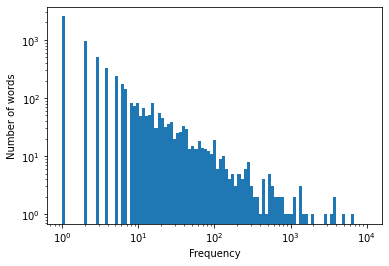

In [21]:
frequencies = list(unigrams.values())
plt.hist(frequencies, bins=np.logspace(0, 4, 100))
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.xlabel('Frequency')
plt.ylabel('Number of words')

Tenemos más de 1000 palabras con una única frecuencia en el corpus. Teniendo en cuenta que la estimación de probabilidad de los n-gramas que contengan estas palabras va a ser en su mayoría cero y de que serían estimados con alta incertidumbre tras haber observado una única ocurrencia en el corpus, estas palabras son buenas candidatas para transformarlas con el token `<UNK>`.

En la siguiente celda vamos a extraer todos los tokens con una única ocurrencia en el corpus:

In [22]:
tokens_to_unknows = set()

for token in unigrams:
    if unigrams[token] == 1:
        tokens_to_unknows.add(token[0])

print(f'{len(tokens_to_unknows):,} tokens con una única ocurrencia en el corpus.')

2,543 tokens con una única ocurrencia en el corpus.


Ahora hacemos un wrapper sobre la clase Corpus que construimos anteriormente, para además de procesar el texto transformar los token con ocurrencia única a el nuevo token `<UNK>`:

In [23]:
class Corpus_with_unks(Corpus):
    def __init__(self, path:int, unks:"list[str]"):
        """
        Clase para crear un corpus de texto iterable

        Args:
            path (int): Ubicación del archivo de texto a usar como corpus
            unks (list[str]): Listado de tokens a transformar a <UNK>
        """
        super().__init__(path)
        self.unks = unks

    def _preprocess(self, line: str):
        """
        Realiza procesamiento de texto y tokenización del texto recibido. También transforma los tokens previamente definidos en <UNK>.

        Args:
            line (str): Texto a procesar y tokenizar. 
        """
        return [token if token not in self.unks else '<UNK>' for token in super()._preprocess(line)]

corpus_with_unks = Corpus_with_unks(CORPUS_PATH, tokens_to_unknows)

Imprimimos la primera secuencia del corpus, y evidenciamos como algunas palasbras fueron transformadas por el token `<UNK>`:

In [24]:
corpus_with_unks[0]

['<START>',
 '<UNK>',
 '<UNK>',
 'OF',
 '<UNK>',
 '<UNK>',
 'In',
 'the',
 'darksome',
 '<UNK>',
 'of',
 'a',
 'thick',
 'forest',
 'lived',
 'Kalyb',
 'the',
 'fell',
 'enchantress',
 '.',
 '<END>']

Ahora construimos nuevamente los modelosde de n-gramas con la inclusión del token `<UNK>`.

In [25]:
unigrams = {}
bigrams = {}
n_grams_freq(bigrams, unigrams, 2, corpus_with_unks)

In [26]:
trigrams = {}
four_grams = {}
n_grams_freq(four_grams, trigrams, 4, corpus_with_unks)

Definimos una función para calcular la probabilidad de una secuencia de texto:

In [27]:
def prob_of_seq(seq, n_grams, n_minus_1_grams):
    """
    Función para calcular la probabilidad de una secuencia de texto según un modelo de n-gramas.

    Args:
        seq (list[str]): Listado de tokens de una secuencia de texto.
        n_grams (dict): Frecuencias de los n-gramas.
        n_minus_1_grams (dict): Frecuencias de los (n-1)-gramas
    """
    n = len(list(n_grams.keys())[0])
    p = 0
    for i in range(len(seq) - n + 1):
        p += np.log(n_grams.get(tuple(seq[i:i+n]), 0) / n_minus_1_grams.get(tuple(seq[i:i+n-1]), 0))
    return np.exp(p)

Probemos una secuencia de texto con palabras fuera del vocabulario:

In [28]:
# Secuencia de texto de ejemplo
sample_seq = "hola, que tal?"

# Procesar y tokenizar la secuencia de texto
sample_seq = corpus_with_unks._preprocess(sample_seq)
sample_seq = [tok if unigrams.get((tok,)) else "<UNK>" for tok in sample_seq]
print(' '.join(sample_seq))

# Para el caso de unigramas el denominador es el número de palabras en el vocabulario
vocab = {tuple(): len(unigrams)}
# Calcular la probabilidad de la secuencia de texto
p_1_gram = prob_of_seq(sample_seq, unigrams, vocab)
print(p_1_gram)

<START> <UNK> , <UNK> <UNK> ? <END>
0.06113260138510626


Al agregar las palabras fuera del vocabulario, podemos calcular la probabilidad de cualquier secuencia de texto.

## 6.2 Agregar suavizado de laplace

Ahora agregaremos el suavizado de Laplace para reservar algo de probabilidad para cualquier combinación posible de tokens. Para lograrlo, vamos a reducir la estimación de probabilidad de las combinaciones que observamos y vamos a asignar un valor de probabilidad mayor a 0 a las combinaciones nunca vistas pero posibles.

$P(w_i|w_{i-n}...w_{i-1}) = \frac{\text{count}(w_{i-n}, ..., w_i)+1}{\text{count}(w_{i-n}, w_{i-1})+V}$ en donde $V$ es el tamaño del vocabulario.

In [29]:
def prob_of_seq_laplace(seq: "list[str]", n_grams: dict, n_minus_1_grams: dict, V: int):
    """
    Función para calcular la probabilidad de una secuencia de texto según un modelo de n-gramas con suavizado de Laplace.

    Args:
        seq (list[str]): Listado de tokens de una secuencia de texto.
        n_grams (dict): Frecuencias de los n-gramas.
        n_minus_1_grams (dict): Frecuencias de los (n-1)-gramas
        V (int): Tamaño del vocabulario
    """
    n = len(list(n_grams.keys())[0])
    p = 0
    for i in range(len(seq) - n + 1):
        p += np.log((n_grams.get(tuple(seq[i:i+n]), 0) + 1) / (n_minus_1_grams.get(tuple(seq[i:i+n-1]), 0) + V))
    return np.exp(p)

Finalmente, podemos calcular nuevamente la probabilidad de una secuencia de texto que no fue observada en el corpus con todos los modelos de n-gramas que construimos.

In [30]:
sample_seq = ["it", "was", "very", "sad"]
print(' '.join(sample_seq))

# Probabilidad de la secuencia de texto con unigramas
vocab = {tuple(): len(unigrams)}
V = len(unigrams)
p_1_gram = prob_of_seq_laplace(sample_seq, unigrams, vocab, V)
print(p_1_gram)

# Probabilidad de la secuencia de texto con bigramas
p_2_gram = prob_of_seq_laplace(sample_seq, bigrams, unigrams, V)
print(p_2_gram)

# Probabilidad de la secuencia de texto con trigramas
p_3_gram = prob_of_seq_laplace(sample_seq, trigrams, bigrams, V)
print(p_3_gram)

# Probabilidad de la secuencia de texto con 4-gramas
p_4_gram = prob_of_seq_laplace(sample_seq, four_grams, trigrams, V)
print(p_4_gram)

it was very sad
4.1590951536331457e-07
1.3183181486252166e-07
1.5840678259825453e-07
0.00028645087367516455


Ya podemos calcular la probabilidad de cualquier secuencia de texto.

# 7. Generación de texto

In [31]:
def generate_text(seed: "list[str]", n_gram_model: dict, n_minus_1_gram_model: dict, V: int, max_len=100):
    """
    Función para generar texto a partir de un modelo de n-gramas.
 
    Args:
        seed (list[str]): Semilla de tokens para comenzar la generación del texto.
        n_gram_model (dict): Modelo de n-gramas.
        n_minus_1_gram_model (dict): Modelo de (n-1)-gramas.
        V (int): Tamaño del vocabulario.
        max_len (int): Longitud máxima del texto a generar.
 
    Returns:
        str: Texto generado a partir del modelo de n-gramas.
    """
    seq = seed.copy()
    # Número de n-gramas
    n = len(list(n_gram_model.keys())[0])
 
    # Verificar que la semilla tenga al menos n-1 tokens
    if len(seq) < n - 1:
        raise "Seed must have at least n-1 tokens"
 
    # Generar el texto
    while len(seq) < max_len:
        # Obtener el contexto de la secuencia para el denominador del suavizado de laplace
        seq_context = tuple(seq[len(seq)-n+1:])
        context_freq = n_minus_1_gram_model.get(seq_context, 0)
 
        # Buscar el siguiente token con la mayor probabilidad
        max_p = 0
        next_token = None
        for n_gram in n_gram_model:
            # Solo considerar n-gramas que tengan el contexto correcto
            if n_gram[:-1] != seq_context:
                continue
            # Calcular la probabilidad del n-grama con suavizado de laplace: P(w_n| context) = (count + 1)
            p = (n_gram_model[n_gram] + 1) / (context_freq + V)
            # Guardar el token con la mayor probabilidad
            if p > max_p:
                max_p = p
                next_token = n_gram[-1]
 
        # Agregar el token al texto generado
        seq.append(next_token)
        # Terminar si se encuentra el token de fin de secuencia
        if next_token == '<END>':
            break
    return ' '.join(seq)
   

Probemos la capacidad de generación de texto de los modelos de n-gramas construidos.

Modelo de unigramas:

In [31]:
# Semilla para nuestro proceso de generación de texto
sample = "Once upon a time"

# Preprocesar la semilla
seed = corpus_with_unks._preprocess(sample)[:-1]
seed = [tok if unigrams.get((tok,)) else "<UNK>" for tok in seed]

print(generate_text(seed, unigrams, vocab, V))

<START> Once upon a time , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,


Modelo de bigramas:

In [32]:
print(generate_text(seed, bigrams, unigrams, V))

<START> Once upon a time , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the <UNK> , and the


Modelo de trigramas:

In [33]:
print(generate_text(seed, trigrams, bigrams, V))

<START> Once upon a time there was a <UNK> , and the little pig had , gave him a good bargain . '' <END>


Modelo de 4-gramas:

In [34]:
print(generate_text(seed, four_grams, trigrams, V))

<START> Once upon a time there was a little girl called Goldilocks , who lived together in a house of their own , in a dark corner of his dungeon , he found one of the most beautiful maiden in the world . <END>


# 8. Conclusiones

Los modelos de n-gramas son fáciles de constuir y tienen la capacidad de generar texto gramaticalmente correcto. Sin embargo, únicamente consideran relaciones de corto plazo en el texto, y ampliar el tamaño del contexto es poco factible debido a que para ser precisos necesitan observar multiples ocurrencias exactas en el corpus de entrenamiento.